# Semantic Similarity Comparison: VectorSage vs. Baselines

This notebook compares the semantic similarity between natural-language user queries and the document titles retrieved by three different systems:

- **VectorSage**: Our semantic search system.
- **LitSense2**: A baseline system (mostly keyword-based).
- **PubMed**: A baseline system (mostly keyword-based).

## Embedding Model Selection

We use the Hugging Face model `sentence-transformers/all-mpnet-base-v2`.

- **Why this model?** It is a highly capable, general-purpose sentence embedding model known to perform well on semantic similarity tasks.
- **Scientific text suitability:** MPNet captures complex semantic dependencies well, making it strong for processing scientific language and nuanced queries.
- **Implementation details:** We bypass the high-level `SentenceTransformer` wrapper and explicitly implement tokenization, mean pooling (with attention masking), and L2 normalization using the base `transformers` and `PyTorch` libraries.

In [1]:
# Cell 1: Imports, Model Loading, and Explicit Encoding Function
import json
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

# Define the model checkpoint
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

# Load tokenizer and model from Hugging Face
print(f"Loading tokenizer and model: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
print("Model loaded successfully.")


Loading tokenizer and model: sentence-transformers/all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully.


In [2]:
def encode_texts(texts):
    """Encodes a list of strings into L2-normalized dense embeddings
    using explicitly implemented mean pooling and attention masking.
    """
    # Ensure we always have a list
    if isinstance(texts, str):
        texts = [texts]

    # Tokenize input texts
    encoded_input = tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt",
    )

    # Compute token embeddings
    with torch.no_grad():
        model_output = model(**encoded_input)

    # Mean Pooling Logic
    token_embeddings = model_output[0]
    attention_mask = encoded_input["attention_mask"]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    pooled_embeddings = sum_embeddings / sum_mask

    # L2 Normalization
    normalized_embeddings = F.normalize(pooled_embeddings, p=2, dim=1)

    return normalized_embeddings.numpy()

In [3]:
# Cell 2: JSON Loading
file_path = "./data/passages_search_results_Final.json"

try:
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    results = data.get("results", [])
    print(f"Successfully loaded {len(results)} queries from {file_path}.")
except FileNotFoundError:
    print(f"Error: {file_path} not found. Please ensure it is in the same directory.")
    results = []

Successfully loaded 11 queries from ./data/passages_search_results_Final.json.


In [4]:
# Cell 3: Main Similarity Computation and DataFrame Construction
systems = ["VectorSage", "LitSense2", "PubMed"]
rows = []

print("Computing embeddings and cosine similarities...")

for query_index, entry in enumerate(results):
    query = entry.get("query", "")
    category = entry.get("category", "")
    sources = entry.get("sources", {})

    # Encode the query into a single embedding (shape: (1, d))
    q_emb = encode_texts([query])

    for sys in systems:
        # Get raw documents and original count
        raw_docs = sources.get(sys, [])
        num_docs = len(raw_docs)

        # Filter out empty or whitespace-only strings
        valid_docs = [doc for doc in raw_docs if isinstance(doc, str) and doc.strip()]

        # Check if we have valid documents
        if valid_docs:
            # Encode documents (shape: (k, d))
            doc_embs = encode_texts(valid_docs)

            # Compute cosine similarities between query and all documents
            sims = cosine_similarity(q_emb, doc_embs)[0]

            # Compute mean over the system's documents
            cosine_mean = np.mean(sims)
        else:
            # No valid documents: use 0 (no result = no similarity)
            cosine_mean = 0.0

        rows.append({
            "query_index": query_index,
            "query": query,
            "category": category,
            "system": sys,
            "num_docs": num_docs,
            "cosine_mean": cosine_mean,
            "has_results": 1 if valid_docs else 0,
        })

# Create the final DataFrame
df = pd.DataFrame(rows)
print("DataFrame construction complete.")
display(df)

Computing embeddings and cosine similarities...
DataFrame construction complete.


,query_index,query,category,system,num_docs,cosine_mean,has_results
0,0,What makes some patients with the same tumor t...,Terminology Gap,VectorSage,3,0.643206,1
1,0,What makes some patients with the same tumor t...,Terminology Gap,LitSense2,3,0.000000,0
2,0,What makes some patients with the same tumor t...,Terminology Gap,PubMed,3,0.000000,0
3,1,Can a sepsis detection algorithm trained befor...,Robustness/Generalization,VectorSage,3,0.675541,1
4,1,Can a sepsis detection algorithm trained befor...,Robustness/Generalization,LitSense2,3,0.000000,0
5,1,Can a sepsis detection algorithm trained befor...,Robustness/Generalization,PubMed,3,0.000000,0
6,2,Can the composition of gut bacteria before sta...,Multi-Hop Concept,VectorSage,3,0.717566,1
7,2,Can the composition of gut bacteria before sta...,Multi-Hop Concept,LitSense2,3,0.000000,0
8,2,Can the composition of gut bacteria before sta...,Multi-Hop Concept,PubMed,3,0.000000,0
9,3,What strategies reduce the risk of kidney dama...,Clinical Treatment,VectorSage,3,0.588434,1


In [5]:
# Cell 4: Pivot Tables (including 0.0 "no result" markers for accurate mean)

# Create pivot with all data including 0.0 for "no result" cases
# This accounts for systems that return no results, lowering their mean appropriately
pivot_mean = df.pivot(
    index=["query_index", "category"],
    columns="system",
    values="cosine_mean",
)

print("\n--- Pivot Table: Mean Cosine Similarity (Including 0.0 'No Result' Cases) ---")
print(f"Rows in pivot: {len(pivot_mean)}")
display(pivot_mean)


--- Pivot Table: Mean Cosine Similarity (Including 0.0 'No Result' Cases) ---
Rows in pivot: 11


,system,LitSense2,PubMed,VectorSage
query_index,category,,,
0,Terminology Gap,0.000000,0.000000,0.643206
1,Robustness/Generalization,0.000000,0.000000,0.675541
2,Multi-Hop Concept,0.000000,0.000000,0.717566
3,Clinical Treatment,0.466365,0.000000,0.588434
4,Lay-Language Clinical Description,0.744974,0.605427,0.766519
5,Pipeline / Workflow,0.000000,0.000000,0.659071
6,Resource-Constrained Setting,0.000000,0.000000,0.438378
7,Human–AI Interaction,0.000000,0.271823,0.656295
8,Ethical / Fairness-Aware Modeling,0.453893,0.474653,0.560982


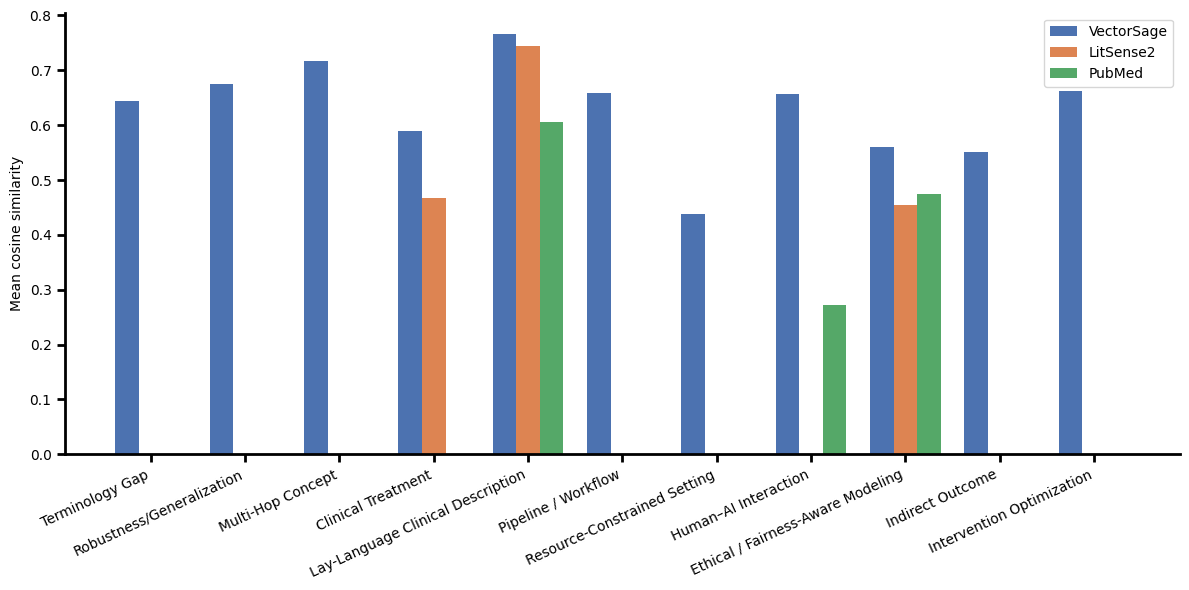

In [6]:
# Visualization: mean cosine similarity per category and system (including 0.0 no results)
import matplotlib.pyplot as plt
import seaborn as sns

# Use pivot_mean if available; if not, recompute from df
try:
    pivot_to_plot = pivot_mean.copy()
except NameError:
    pivot_to_plot = df.pivot(
        index=["query_index", "category"],
        columns="system",
        values="cosine_mean",
    )

# Flatten index so we can use category labels on x-axis
pivot_plot = pivot_to_plot.reset_index()

# Get seaborn deep palette
deep_palette = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(pivot_plot))
width = 0.25

ax.bar(x - width, pivot_plot["VectorSage"], width, label="VectorSage", color=deep_palette[0])
ax.bar(x,         pivot_plot["LitSense2"],  width, label="LitSense2", color=deep_palette[1])
ax.bar(x + width, pivot_plot["PubMed"],     width, label="PubMed", color=deep_palette[2])

ax.set_xticks(x)
ax.set_xticklabels(pivot_plot["category"], rotation=25, ha="right")
ax.set_ylabel("Mean cosine similarity")
ax.set_title("")
ax.legend()

# Remove spines (box)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Increase tick line thickness (major ticks)
ax.tick_params(axis='both', which='major', width=2, length=6)
ax.tick_params(axis='both', which='minor', width=3, length=4)

plt.tight_layout()
plt.savefig('./Figures/mean_cosine_similarity_per_category_passage.tiff', dpi=300, bbox_inches='tight')
plt.savefig('./Figures/mean_cosine_similarity_per_category_passage.svg', dpi=300, bbox_inches='tight')
plt.show()

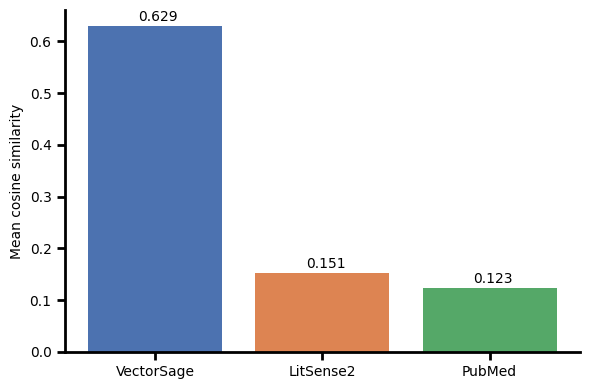

Mean cosine similarity per system (including 0.0 'no result' markers):
system
VectorSage    0.628950
LitSense2     0.151385
PubMed        0.122900
Name: cosine_mean, dtype: float64


In [7]:
# Visualization: overall mean cosine similarity per system (including 0.0 for no results)
import matplotlib.pyplot as plt
import seaborn as sns

# Compute overall mean cosine similarity per system, INCLUDING 0.0 values
# This accounts for systems that return no results (0.0), which lowers their mean
mean_per_system = df.groupby("system")["cosine_mean"].mean().reindex(["VectorSage", "LitSense2", "PubMed"])

# Get seaborn deep palette
deep_palette = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(mean_per_system.index, mean_per_system.values, color=[deep_palette[0], deep_palette[1], deep_palette[2]])
ax.set_ylabel("Mean cosine similarity")
ax.set_title("")

# Remove spines (box)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Increase tick line thickness (major ticks)
ax.tick_params(axis='both', which='major', width=2, length=6)
ax.tick_params(axis='both', which='minor', width=3, length=4)
ax.annotate(f"{mean_per_system['VectorSage']:.3f}", xy=(0, mean_per_system['VectorSage']), xytext=(-0.1, mean_per_system['VectorSage'] + 0.01),
            fontsize=10, color='black')
ax.annotate(f"{mean_per_system['LitSense2']:.3f}", xy=(1, mean_per_system['LitSense2']), xytext=(0.9, mean_per_system['LitSense2'] + 0.01),
            fontsize=10, color='black')
ax.annotate(f"{mean_per_system['PubMed']:.3f}", xy=(2, mean_per_system['PubMed']), xytext=(1.9, mean_per_system['PubMed'] + 0.01),
            fontsize=10, color='black')

plt.tight_layout()
plt.savefig('./Figures/overall_mean_cosine_similarity_per_system_passage.tiff', dpi=300, bbox_inches='tight')
plt.savefig('./Figures/overall_mean_cosine_similarity_per_system_passage.svg', dpi=300, bbox_inches='tight')
plt.show()

print("Mean cosine similarity per system (including 0.0 'no result' markers):")
print(mean_per_system)

In [8]:
# Per-document similarities: one row per query–system–document (no averaging)

rows_docs = []
systems = ["VectorSage", "LitSense2", "PubMed"]

print("Computing per-document similarities...")

for query_index, entry in enumerate(results):
    query = entry.get("query", "")
    category = entry.get("category", "")
    sources = entry.get("sources", {})

    if not query:
        continue

    # Encode query once per entry
    q_emb = encode_texts([query])  # shape: (1, d)

    for sys in systems:
        docs_raw = sources.get(sys, []) or []

        if not docs_raw:
            # Represent a "no result" as a single empty doc so it appears explicitly
            docs_raw = [""]

        # Use empty string as-is for embedding so similarity stays low
        docs_for_embed = [doc if isinstance(doc, str) else "" for doc in docs_raw]

        doc_embs = encode_texts(docs_for_embed)  # shape: (k, d)
        sims = cosine_similarity(q_emb, doc_embs)[0]  # shape: (k,)

        for doc_idx, (doc_text, sim) in enumerate(zip(docs_raw, sims)):
            rows_docs.append({
                "query_index": query_index,
                "query": query,
                "category": category,
                "system": sys,
                "doc_index": doc_idx,
                "title": doc_text,
                "cosine": float(sim),
            })

df_docs = pd.DataFrame(rows_docs)
print("Per-document DataFrame shape:", df_docs.shape)
display(df_docs.head())

Computing per-document similarities...
Per-document DataFrame shape: (99, 7)


,query_index,query,category,system,doc_index,title,cosine
0,0,What makes some patients with the same tumor t...,Terminology Gap,VectorSage,0,Checkpoint blockade has demonstrated promising...,0.612108
1,0,What makes some patients with the same tumor t...,Terminology Gap,VectorSage,1,Immune checkpoint blockade therapy can elicit ...,0.669123
2,0,What makes some patients with the same tumor t...,Terminology Gap,VectorSage,2,Treatment of cancer has transformed with the i...,0.648386
3,0,What makes some patients with the same tumor t...,Terminology Gap,LitSense2,0,,-0.042799
4,0,What makes some patients with the same tumor t...,Terminology Gap,LitSense2,1,,-0.042799


Computing per-document similarities...
Per-document DataFrame shape: (99, 7)


,query_index,query,category,system,doc_index,title,cosine
0,0,What makes some patients with the same tumor t...,Terminology Gap,VectorSage,0,Checkpoint blockade has demonstrated promising...,0.612108
1,0,What makes some patients with the same tumor t...,Terminology Gap,VectorSage,1,Immune checkpoint blockade therapy can elicit ...,0.669123
2,0,What makes some patients with the same tumor t...,Terminology Gap,VectorSage,2,Treatment of cancer has transformed with the i...,0.648386
3,0,What makes some patients with the same tumor t...,Terminology Gap,LitSense2,0,,0.000000
4,0,What makes some patients with the same tumor t...,Terminology Gap,LitSense2,1,,0.000000


,query_index,query,category,system,doc_index,title,cosine,success_label
0,0,What makes some patients with the same tumor t...,Terminology Gap,VectorSage,0,Checkpoint blockade has demonstrated promising...,0.612108,Partially relevant
1,0,What makes some patients with the same tumor t...,Terminology Gap,VectorSage,1,Immune checkpoint blockade therapy can elicit ...,0.669123,Relevant
2,0,What makes some patients with the same tumor t...,Terminology Gap,VectorSage,2,Treatment of cancer has transformed with the i...,0.648386,Partially relevant
3,0,What makes some patients with the same tumor t...,Terminology Gap,LitSense2,0,,0.000000,No result
4,0,What makes some patients with the same tumor t...,Terminology Gap,LitSense2,1,,0.000000,No result


Wrote per-document labeled results to ./data/query_results_docs_scored_passage.json


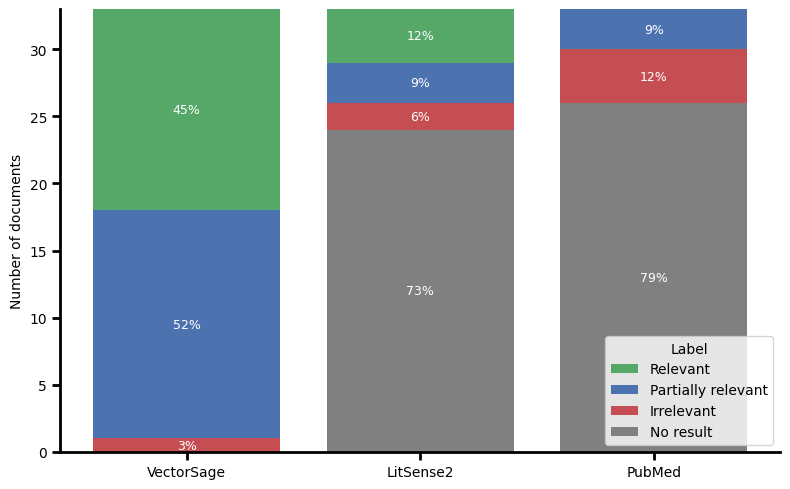

In [9]:
# Per-document similarities: one row per query–system–document (no averaging)

rows_docs = []
systems = ["VectorSage", "LitSense2", "PubMed"]

print("Computing per-document similarities...")

for query_index, entry in enumerate(results):
    query = entry.get("query", "")
    category = entry.get("category", "")
    sources = entry.get("sources", {})

    if not query:
        continue

    # Encode query once per entry
    q_emb = encode_texts([query])  # shape: (1, d)

    for sys in systems:
        docs_raw = sources.get(sys, []) or []

        if not docs_raw:
            # Represent a "no result" as a single empty doc so it appears explicitly
            docs_raw = [""]

        # Separate empty and non-empty documents
        for doc_idx, doc_text in enumerate(docs_raw):
            if isinstance(doc_text, str) and doc_text.strip():
                # Non-empty document: embed and compute similarity
                doc_emb = encode_texts([doc_text])
                sim = float(cosine_similarity(q_emb, doc_emb)[0][0])
            else:
                # Empty document: assign 0.0 as marker for "no result"
                sim = 0.0

            rows_docs.append({
                "query_index": query_index,
                "query": query,
                "category": category,
                "system": sys,
                "doc_index": doc_idx,
                "title": doc_text,
                "cosine": sim,
            })

df_docs = pd.DataFrame(rows_docs)
print("Per-document DataFrame shape:", df_docs.shape)
display(df_docs.head())

# Per-document labeling and JSON export + visualization

def success_label_doc(score: float) -> str:
    if score == 0.0:  # This condition is never true; 0.0 will be caught by the next condition
        return "No result"
    elif score >= 0.65:
        return "Relevant"
    elif score >= 0.40:
        return "Partially relevant"
    else:
        return "Irrelevant"

if "cosine" not in df_docs.columns:
    raise ValueError("df_docs must contain a 'cosine' column with per-document similarities.")

# Label each individual document
df_docs_labeled = df_docs.copy()
df_docs_labeled["success_label"] = df_docs_labeled["cosine"].apply(success_label_doc)

display(df_docs_labeled.head())

# Build a JSON structure with labels per query, per system, per document
labeled_doc_results = []
for q_idx, group_q in df_docs_labeled.groupby("query_index"):
    entry = {
        "query_index": int(q_idx),
        "query": group_q["query"].iloc[0],
        "category": group_q["category"].iloc[0],
        "systems": {},
    }
    for sys, group_sys in group_q.groupby("system"):
        docs_list = []
        for _, row in group_sys.sort_values("doc_index").iterrows():
            docs_list.append({
                "doc_index": int(row["doc_index"]),
                "title": row["title"],
                "cosine": float(row["cosine"]),
                "label": row["success_label"],
            })
        entry["systems"][sys] = docs_list
    labeled_doc_results.append(entry)


output_docs_path = "./data/query_results_docs_scored_passage.json"
with open(output_docs_path, "w", encoding="utf-8") as f:
    json.dump({"results": labeled_doc_results}, f, indent=2, ensure_ascii=False)

print(f"Wrote per-document labeled results to {output_docs_path}")

# Visualization: per-document label distribution per system (percentages)
import seaborn as sns

label_counts_docs = (
    df_docs_labeled
    .groupby(["system", "success_label"])
    .size()
    .reset_index(name="count")
)

total_per_system_docs = label_counts_docs.groupby("system")["count"].sum()

label_order = [
    "No result",
    "Irrelevant",
    "Partially relevant",
    "Relevant"
]

# Get seaborn deep palette
deep_palette = sns.color_palette("deep")
label_colors = {
    "Relevant": deep_palette[2],
    "Partially relevant": deep_palette[0],
    "Irrelevant": deep_palette[3],
    "No result": "#808080"
}

# systems_docs = sorted(df_docs_labeled["system"].unique())
systems_docs = systems

fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(systems_docs))

for label in label_order:
    counts = []
    percents = []
    for i, sys in enumerate(systems_docs):
        row = label_counts_docs[(label_counts_docs["system"] == sys) & (label_counts_docs["success_label"] == label)]
        c = int(row["count"].iloc[0]) if not row.empty else 0
        counts.append(c)
        total = int(total_per_system_docs.loc[sys]) if sys in total_per_system_docs else 0
        perc = (c / total * 100) if total > 0 else 0.0
        percents.append(perc)

    counts = np.array(counts)
    bars = ax.bar(systems_docs, counts, bottom=bottom, label=label, color=label_colors[label])

    for i, bar in enumerate(bars):
        if counts[i] == 0:
            continue
        height = bar.get_height()
        y = bar.get_y() + height / 2
        ax.text(bar.get_x() + bar.get_width() / 2, y, f"{percents[i]:.0f}%",
                ha="center", va="center", fontsize=9, color="white")

    bottom += counts

ax.set_ylabel("Number of documents")
ax.set_title("")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="Label")

# Remove spines (box)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Increase tick line thickness
ax.tick_params(axis='both', which='major', width=2, length=6)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('./Figures/per_document_relevance_label_distribution_passage.tiff', dpi=300, bbox_inches='tight')
plt.savefig('./Figures/per_document_relevance_label_distribution_passage.svg', dpi=300, bbox_inches='tight')
plt.show()

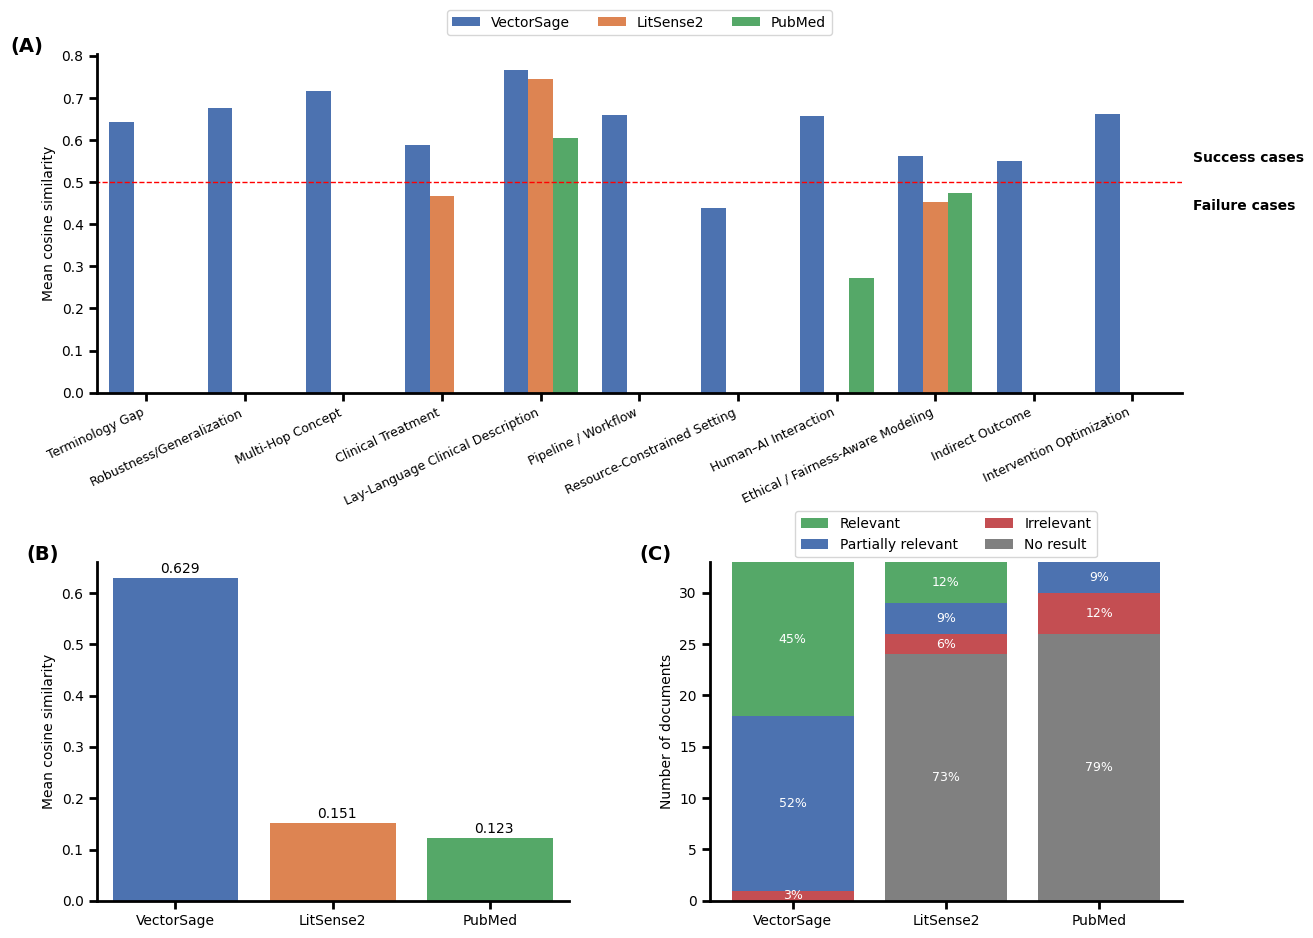

In [22]:
# Combined visualization: first figure on top, two others below side-by-side
import matplotlib.pyplot as plt
import seaborn as sns

system_display = {
    "VectorSage": "VectorSage",
    "LitSense2": "LitSense2",
    "PubMed": "PubMed"
}

# Get seaborn deep palette
deep_palette = sns.color_palette("deep")

# Create figure with GridSpec: 2 rows, 2 columns
fig = plt.figure(figsize=(14, 11))
gs = fig.add_gridspec(2, 2, hspace=0.5, wspace=0.3)

# Top plot spans both columns
ax1 = fig.add_subplot(gs[0, :])

# Bottom plots: left and right
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# --- TOP PLOT: Mean cosine similarity per category and system (including 0.0) ---
pivot_plot_data = df.pivot(
    index=["query_index", "category"],
    columns="system",
    values="cosine_mean",
).reset_index()

x = np.arange(len(pivot_plot_data))
width = 0.25

ax1.bar(x - width, pivot_plot_data["VectorSage"], width, label="VectorSage", color=deep_palette[0])
ax1.bar(x,         pivot_plot_data["LitSense2"],  width, label="LitSense2", color=deep_palette[1])
ax1.bar(x + width, pivot_plot_data["PubMed"],     width, label="PubMed", color=deep_palette[2])

ax1.set_xticks(x)
ax1.set_xticklabels(pivot_plot_data["category"], rotation=25, ha="right", fontsize=9)
ax1.set_ylabel("Mean cosine similarity")
ax1.set_title("")
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)

# Remove spines (box)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# Increase tick line thickness (major ticks)
ax1.tick_params(axis='both', which='major', width=2, length=6)
ax1.tick_params(axis='both', which='minor', width=3, length=4)

# Add (A) label
ax1.text(-0.08, 1.05, '(A)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')

from matplotlib.transforms import blended_transform_factory

ax1.hlines(y=0.5, xmin=-2.5, xmax=14.0, colors='red', linestyles='dashed', linewidth=1)

trans = blended_transform_factory(ax1.transAxes, ax1.transData)

ax1.text(1.01, 0.5 + 0.04, 'Success cases', fontsize=10, color='black',
         fontweight='bold', transform=trans, va='bottom', ha='left')

ax1.text(1.01, 0.5 - 0.04, 'Failure cases', fontsize=10, color='black',
         fontweight='bold', transform=trans, va='top', ha='left')

# Set tight x-axis limits to remove extra space
ax1.set_xlim(-0.5, len(pivot_plot_data) - 0.5)

# --- BOTTOM LEFT PLOT: Overall mean cosine similarity per system (including 0.0) ---
mean_per_system = df.groupby("system")["cosine_mean"].mean().reindex(["VectorSage", "LitSense2", "PubMed"])
display_index = [system_display[s] for s in mean_per_system.index]

bar_width = 0.8
ax2.bar(display_index, mean_per_system.values, width=bar_width, color=[deep_palette[0], deep_palette[1], deep_palette[2]])
ax2.set_ylabel("Mean cosine similarity")
ax2.set_title("")
ax2.set_xlim(-0.5, 2.5)

# Remove spines (box)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(2)
ax2.spines['bottom'].set_linewidth(2)

# Increase tick line thickness (major ticks)
ax2.tick_params(axis='both', which='major', width=2, length=6)
ax2.tick_params(axis='both', which='minor', width=3, length=4)

# Add (B) label
ax2.text(-0.15, 1.05, '(B)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')
ax2.annotate(f"{mean_per_system['VectorSage']:.3f}", xy=(0, mean_per_system['VectorSage']), xytext=(-0.1, mean_per_system['VectorSage'] + 0.01),
                fontsize=10, color='black')
ax2.annotate(f"{mean_per_system['LitSense2']:.3f}", xy=(1, mean_per_system['LitSense2']), xytext=(0.9, mean_per_system['LitSense2'] + 0.01),
                fontsize=10, color='black')
ax2.annotate(f"{mean_per_system['PubMed']:.3f}", xy=(2, mean_per_system['PubMed']), xytext=(1.9, mean_per_system['PubMed'] + 0.01),
                fontsize=10, color='black')

# --- BOTTOM RIGHT PLOT: Per-document label distribution (including "No result") ---
label_counts_docs = (
    df_docs_labeled
    .groupby(["system", "success_label"])
    .size()
    .reset_index(name="count")
)

total_per_system_docs = label_counts_docs.groupby("system")["count"].sum()

label_order = [
    "No result",
    "Irrelevant",
    "Partially relevant",
    "Relevant"
]

label_colors = {
    "Relevant": deep_palette[2],
    "Partially relevant": deep_palette[0],
    "Irrelevant": deep_palette[3],
    "No result": "#808080"
}

systems_docs = systems

bottom = np.zeros(len(systems_docs))

for label in label_order:
    counts = []
    percents = []
    for i, sys in enumerate(systems_docs):
        row = label_counts_docs[(label_counts_docs["system"] == sys) & (label_counts_docs["success_label"] == label)]
        c = int(row["count"].iloc[0]) if not row.empty else 0
        counts.append(c)
        total = int(total_per_system_docs.loc[sys]) if sys in total_per_system_docs else 0
        perc = (c / total * 100) if total > 0 else 0.0
        percents.append(perc)

    counts = np.array(counts)
    display_systems = [system_display[s] for s in systems_docs]

    bars = ax3.bar(display_systems, counts, width=bar_width, bottom=bottom, label=label, color=label_colors[label])

    for i, bar in enumerate(bars):
        if counts[i] == 0:
            continue
        height = bar.get_height()
        y = bar.get_y() + height / 2
        ax3.text(bar.get_x() + bar.get_width() / 2, y, f"{percents[i]:.0f}%",
                ha="center", va="center", fontsize=9, color="white")

    bottom += counts

ax3.set_ylabel("Number of documents")
ax3.set_title("")
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(handles[::-1], labels[::-1], loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol=2)

# Remove spines (box)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_linewidth(2)
ax3.spines['bottom'].set_linewidth(2)

# Increase tick line thickness
ax3.tick_params(axis='both', which='major', width=2, length=6)

# Add (C) label
ax3.text(-0.15, 1.05, '(C)', transform=ax3.transAxes, fontsize=14, fontweight='bold', va='top')

plt.savefig('./Figures/combined_cosine_similarity_figures_passage.tiff', dpi=300, bbox_inches='tight')
plt.savefig('./Figures/combined_cosine_similarity_figures_passage.svg', bbox_inches='tight')
plt.show()